# Linear Regression Analysis

This notebook builds a low-dimensional orientation response manifold from STA-derived pattern activity, then tests whether each target response can be reconstructed as a non-negative combination of stimulation patterns.

In [29]:
# STAs - oracle patterns
import numpy as np

data = np.load(
    '/Users/bhaishahster/Downloads/patterns_and_stas/oracle_pattern_stas.npz',
    allow_pickle=True
)

stas = data['sta'] # patterns x neurons x time
print(stas.shape)
basis = stas.sum(2)

(50, 71, 34)


In [30]:
# STAs
import numpy as np

data = np.load(
    '/Users/bhaishahster/Downloads/stas.npy',
    allow_pickle=True
)

stas = np.reshape(data, [-1, data.shape[2], data.shape[3]]) # patterns x neurons x time
print(stas.shape)
basis = stas.sum(2) # patterns x neurons

(84, 63, 5)


In [31]:
basis.shape

(84, 63)

## Build Target Response Vectors

The STA tensor is collapsed across time to form a pattern-by-neuron basis. From that basis, the notebook creates synthetic average population responses arranged over eight orientation conditions and defines a compact PCA projection for visualization.

In [32]:
import numpy as np
from sklearn.decomposition import PCA

# Parameters
NEURONS = basis.shape[1]  # number of neurons
MEAN_SCALE = 100
RADIUS = 30
ANGLES = np.linspace(0, 2*np.pi, 8, endpoint=False)   # 8 grating directions

# -----------------------------
# Generate two random encoding directions
# -----------------------------
rng = np.random.default_rng(0)

dir1 = rng.normal(size=NEURONS)
dir2 = rng.normal(size=NEURONS)

# Normalize directions
dir1 /= np.linalg.norm(dir1)
dir2 -= dir1 * np.dot(dir1, dir2)   # make orthogonal to dir1
dir2 /= np.linalg.norm(dir2)

# Mean firing vector
mean_vec = MEAN_SCALE * basis.mean(0) #np.ones(NEURONS) * MEAN_SPIKES

# -----------------------------
# Generate average population response vectors
# Shape = (8 angles, 71 neurons)
# -----------------------------
avg_vectors = []

for theta in ANGLES:
    response = (
        mean_vec
        + RADIUS * np.cos(theta) * dir1
        + RADIUS * np.sin(theta) * dir2
    )
    avg_vectors.append(response)

avg_vectors = np.array(avg_vectors)

# -----------------------------
# Compute projection basis
# -----------------------------
pca = PCA(n_components=2)
pca.fit(avg_vectors)

proj, _ = np.linalg.qr(
    np.array([
        avg_vectors.mean(0),
        pca.components_[0],
        pca.components_[1]
    ]).T
)

# Project responses into 3D basis
avg_proj = avg_vectors.dot(proj)

print("avg_vectors shape:", avg_vectors.shape)   # (8,71)
print("proj shape:", proj.shape)                 # (71,3)
print("avg_proj shape:", avg_proj.shape)         # (8,3)
print(avg_proj)

avg_vectors shape: (8, 63)
proj shape: (63, 3)
avg_proj shape: (8, 3)
[[-2.77169193e+02  2.97231308e+01 -4.54252362e-15]
 [-2.76462429e+02  2.09511772e+01  2.12075720e+01]
 [-2.73787644e+02 -9.36918316e-02  2.99920359e+01]
 [-2.70711691e+02 -2.10836775e+01  2.12075720e+01]
 [-2.69036420e+02 -2.97231308e+01 -8.30409231e-17]
 [-2.69743184e+02 -2.09511772e+01 -2.12075720e+01]
 [-2.72417969e+02  9.36918316e-02 -2.99920359e+01]
 [-2.75493923e+02  2.10836775e+01 -2.12075720e+01]]


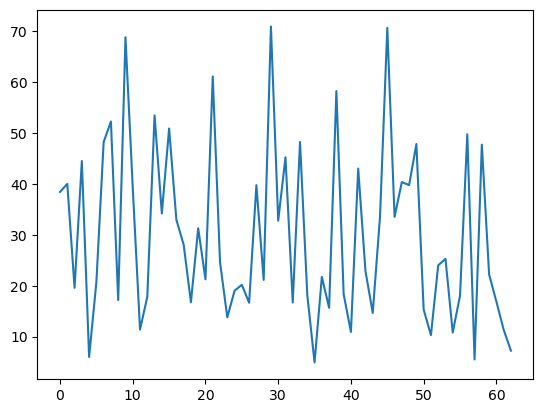

In [33]:
import matplotlib.pyplot as plt
plt.plot(mean_vec)

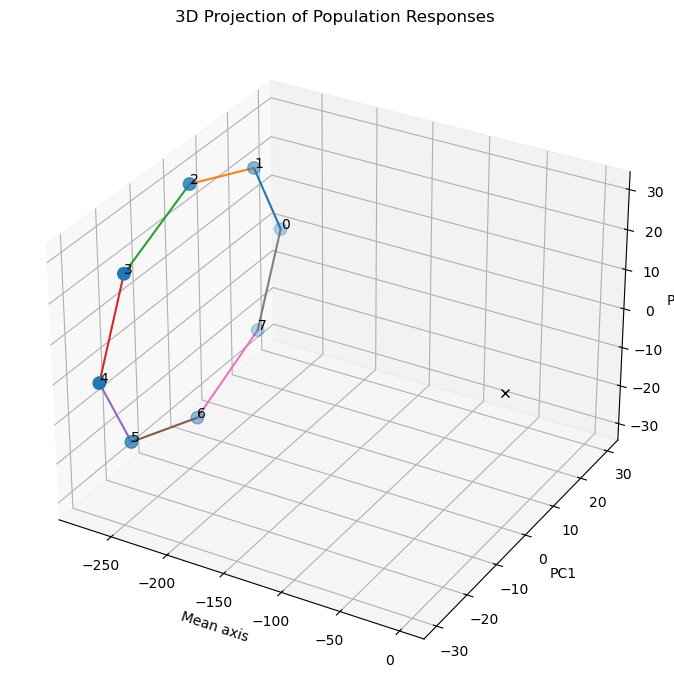

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# avg_proj has shape (8, 3)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(
    avg_proj[:, 0],
    avg_proj[:, 1],
    avg_proj[:, 2],
    s=80
)

# Connect points in order of angle
for i in range(len(avg_proj)):
    j = (i + 1) % len(avg_proj)   # wrap around
    ax.plot(
        [avg_proj[i, 0], avg_proj[j, 0]],
        [avg_proj[i, 1], avg_proj[j, 1]],
        [avg_proj[i, 2], avg_proj[j, 2]],
        linewidth=1.5
    )

ax.plot( 0, 0, 0, 'kx')

# Label each point with angle index
for i in range(len(avg_proj)):
    ax.text(
        avg_proj[i, 0],
        avg_proj[i, 1],
        avg_proj[i, 2],
        f"{i}",
        fontsize=10
    )

ax.set_xlabel("Mean axis")
ax.set_ylabel("PC1")
ax.set_zlabel("PC2")
ax.set_title("3D Projection of Population Responses")

plt.tight_layout()
plt.show()

## Fit Non-Negative Pattern Weights

Each orientation target is approximated with a non-negative least-squares solve over the stimulation basis. This identifies the mixture of available patterns that best reproduces the target response while keeping all weights positive.

## Inspect Basis Usage and Reconstruction Quality

The next plots summarize the basis itself, the recovered stimulation coefficients across targets, and the geometric relationship between the original target vectors and their fitted reconstructions.

In [35]:
# Full dimensional space:
# target vectors: avg_vectors # (n_orientations, n_pca_neurons)
# Dictionary elements: sta_spkcount # dictionary with keys (ch, amp) and values (n_pca_neurons,)

# Use CVXPY to solve the following optimization problem: 
# for a target pattern, find the non-negative linear combination of stimulation patterns that best approximates the target.
# min_x || A x - b||_2^2  subject to x >= 0
import cvxpy as cp
def solve_nonneg_least_squares(A, b):
    """
    Solve min_x || A x - b||_2^2 subject to x >= 0
    A: (n_features, n_patterns)
    b: (n_features,)
    Returns:
        x_opt: (n_patterns,) optimal non-negative coefficients
        residual_norm: scalar, ||A x_opt - b||_2
    """
    n_patterns = A.shape[1]
    x = cp.Variable(n_patterns, nonneg=True)
    # x = cp.Variable(n_patterns, nonneg=False)
    objective = cp.Minimize(cp.sum_squares(A @ x - b))
    problem = cp.Problem(objective)
    problem.solve(solver=cp.OSQP, verbose=False)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        raise ValueError(f"Optimization failed with status: {problem.status}")

    x_opt = x.value
    residual_norm = np.linalg.norm(A @ x_opt - b)
    return x_opt, residual_norm

# A, b in full dimensional space
A = basis.T
approx_log = []
approx_discretized_log = []
stim_log = []
for itarget in range(avg_vectors.shape[0]):
    b = avg_vectors[itarget]  # Target: mean response to first orientation (0 degrees)  
    
    #HACK: number of neurons is different in A and b, so slice b to match A's neuron count for now. In a real scenario, we would need to ensure these are aligned properly. 
    A = A[:b.shape[0], :]

    x_opt, residual_norm = solve_nonneg_least_squares(A, b)
    # Now plot the target vector b and the approximation A x_opt in PC space for comparison.
    approx = (A @ x_opt)[None, :]  
    approx_discrete = (A @ np.round(x_opt))[None, :]
    approx_log.append(approx)
    approx_discretized_log.append(approx_discrete)
    stim_log.append(x_opt)


approx_log = np.squeeze(np.array(approx_log))
approx_proj = approx_log.dot(proj)

approx_discretized_log = np.squeeze(np.array(approx_discretized_log))
approx_discretized_proj = approx_discretized_log.dot(proj)


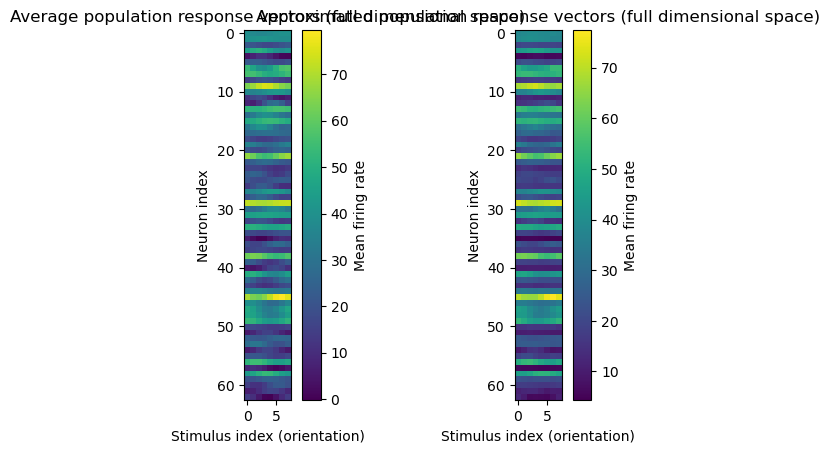

In [36]:
plt.subplot(1, 2, 1)
plt.imshow(avg_vectors.T)
plt.ylabel("Neuron index")
plt.xlabel("Stimulus index (orientation)")
plt.title("Average population response vectors (full dimensional space)")
plt.colorbar(label="Mean firing rate")

plt.subplot(1, 2, 2)
plt.imshow(approx_log.T)
plt.ylabel("Neuron index")
plt.xlabel("Stimulus index (orientation)")
plt.title("Approximated population response vectors (full dimensional space)")
plt.colorbar(label="Mean firing rate")

plt.show()

Text(0.5, 0, 'Electrical stimulation patterns')

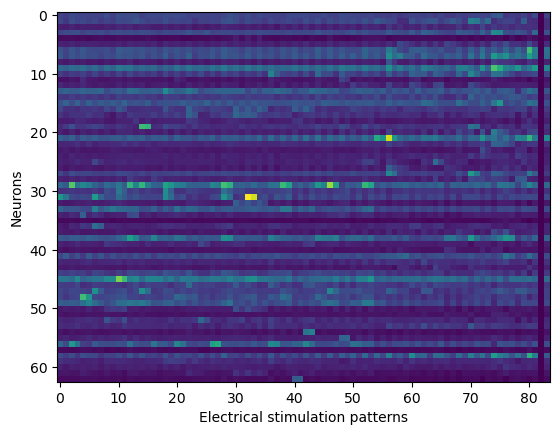

In [37]:
plt.imshow(basis.T)
plt.ylabel('Neurons')
plt.xlabel('Electrical stimulation patterns')

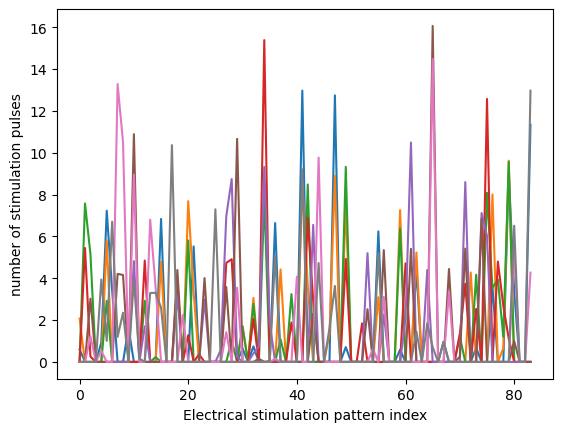

In [38]:
plt.plot(np.array(stim_log).T)
plt.xlabel('Electrical stimulation pattern index')
plt.ylabel('number of stimulation pulses')
plt.show()




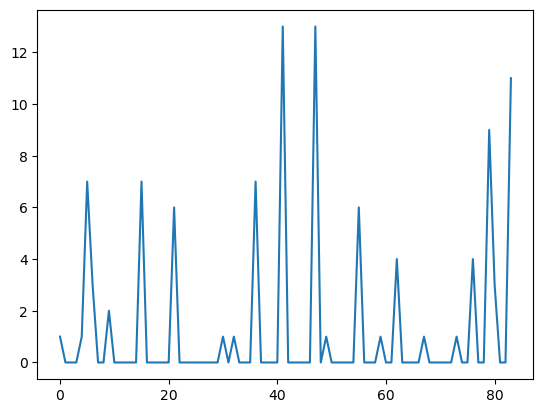

In [39]:
plt.plot(np.round(stim_log[0]))

## Compare Targets and Reconstructions in 3D

This final view overlays each orientation target with its fitted approximation in the shared projection basis. Matching points suggest the non-negative reconstruction preserves the intended response geometry, while visible offsets highlight orientations that are harder to reproduce with the available stimulation patterns.

In [40]:
import plotly.graph_objects as go

# make this a function that I can call at other places
# Orientation colormap
ori_cmap   = plt.get_cmap("hsv")
ori_colors = {a: ori_cmap(i / len(ANGLES)) for i, a in enumerate(ANGLES * 180 / np.pi)}


proj, _ = np.linalg.qr(np.array([avg_vectors.mean(0), pca.components_[0], pca.components_[1]]).T)
avg_proj = avg_vectors.dot(proj)

def rgba_from_mpl(c, alpha=1.0):
    """Convert a matplotlib color tuple (r,g,b,a) to a plotly rgba string."""
    r, g, b, _ = c
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"

traces = []
for i, angle in enumerate(ANGLES * 180 / np.pi):
    color = rgba_from_mpl(ori_colors[angle])
    traces.append(go.Scatter3d(
        x=[avg_proj[i, 0]], y=[avg_proj[i, 1]], z=[avg_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"{angle}°",
    ))


    traces.append(go.Scatter3d(
        x=[approx_proj[i, 0]], y=[approx_proj[i, 1]], z=[approx_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, symbol="square", line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"Approx: {angle}°",
    ))

    traces.append(go.Scatter3d(
        x=[approx_discretized_proj[i, 0]], y=[approx_discretized_proj[i, 1]], z=[approx_discretized_proj[i, 2]],
        mode="markers+text",
        marker=dict(size=8, color=color, symbol="diamond", line=dict(color="black", width=1)),
        text=[f"{angle}°"],
        textposition="top center",
        name=f"Approx discrete: {angle}°",
    ))

# Origin marker
traces.append(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode="markers",
    marker=dict(size=10, color="black", symbol="x"),
    name="Zero",
))

fig = go.Figure(data=traces)
fig.update_layout(
    title="PCA of Average Visual Response Vectors",
    scene=dict(
        xaxis_title="Proj 1",
        yaxis_title="Proj 2",
        zaxis_title="Proj 3",
    ),
    legend=dict(title="Orientation"),
    width=800, height=650,
)
fig.show()
